# Random Forest Model

[Scikit Learn Source](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)

In [22]:
import src.utils.utils as ut
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
wine_df = pd.read_csv(ut.get_project_file_path("src", "data", "transformed", "wines_clean.csv"))
wine_df = wine_df.reset_index(drop=False,)
wine_df = wine_df.rename(columns={"index": "wine_id"})
wine_df

,wine_id,wine_link,name,year,winery,rating,rating_qty,price,body,tannins,...,San Carlos,San Juan,San Rafael,Serra Gaúcha,Tulum Valley,Tunuyán,Tupungato,Uco Valley,Vale dos Vinhedos,Vista Flores
0,0,https://www.vivino.com/US/en/luigi-bosca-parai...,Paraiso,2020.0,Luigi Bosca,4.8,582.0,188.33,0.7343,0.5090,...,0,0,0,0,0,0,0,0,0,0
1,1,https://www.vivino.com/US/en/catena-zapata-est...,Estiba Reservada,2015.0,Catena Zapata,4.7,297.0,675.00,0.7417,0.5583,...,0,0,0,0,0,0,0,0,0,0
2,2,https://www.vivino.com/US/en/catena-zapata-est...,Estiba Reservada,2017.0,Catena Zapata,4.7,219.0,580.00,0.7417,0.5583,...,0,0,0,0,0,0,0,0,0,0
3,3,https://www.vivino.com/US/en/monteviejo-la-vio...,La Violeta,2013.0,Monteviejo,4.7,202.0,150.00,0.7306,0.4091,...,0,0,0,0,0,0,0,1,0,0
4,4,https://www.vivino.com/US/en/vina-cobos-cobos-...,Cobos Volturno,2018.0,Viña Cobos,4.7,198.0,399.99,0.7105,0.4563,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1950,1950,https://www.vivino.com/etchart-cafayate-terroi...,Cafayate Terroir de Altura Torrontés,2021.0,Bodegas Etchart,3.9,110.0,16.99,0.4789,0.3701,...,0,0,0,0,0,0,0,0,0,0
1951,1951,https://www.vivino.com/siesta-cabernet-sauvign...,Cabernet Sauvignon,2011.0,Siesta,3.9,108.0,23.63,0.6515,0.5417,...,0,0,0,0,0,0,0,0,0,0
1952,1952,https://www.vivino.com/gen-del-alma-jijiji-mal...,JIJIJI Malbec - Pinot Noir,2022.0,Gen del Alma,3.9,105.0,22.66,0.6311,0.4507,...,0,0,0,0,0,0,1,1,0,0
1953,1953,https://www.vivino.com/terrazas-de-los-andes-h...,High Altitude Vineyards Malbec,2021.0,Terrazas de los Andes,3.9,103.0,10.99,0.6266,0.3178,...,0,0,0,0,0,0,0,0,0,0


In [4]:
users_data = pd.read_pickle(ut.get_project_file_path("src", "data", "synthetic", "simulation_01_n1000.pkl"))
users_data = users_data.dropna()

In [5]:
recommend_df = pd.merge(wine_df, users_data, how="inner", on="wine_id")
recommend_df

,wine_id,wine_link,name,year,winery,rating,rating_qty,price,body,tannins,...,Tupungato,Uco Valley,Vale dos Vinhedos,Vista Flores,user_id,user_input,metrics_local,metrics_global,liked,prob_like
0,0,https://www.vivino.com/US/en/luigi-bosca-parai...,Paraiso,2020.0,Luigi Bosca,4.8,582.0,188.33,0.7343,0.5090,...,0,0,0,0,335,"{'meal': 'Empanadas de Pollo', 'main_pairing':...",rating_rscld 2.5 price_rscld ...,rating_rscld_gbl 2.666667 price_rscl...,1.0,0.718536
1,11,https://www.vivino.com/US/en/catena-zapata-mal...,Malbec Argentino,2020.0,Catena Zapata,4.6,3695.0,66.67,0.6770,0.3338,...,0,0,0,0,391,"{'meal': 'Carne con Salsa de Champiñones', 'ma...",rating_rscld 1.5 price_rscld ...,rating_rscld_gbl 2.0 price_rscl...,0.0,0.832136
2,99,https://www.vivino.com/penedo-borges-penedo-bo...,Penedo Borges Icono Edicion Aniversario,2018.0,Otaviano,4.4,103.0,38.84,0.5033,0.4399,...,0,0,0,0,681,"{'meal': 'Roquefort con Nueces', 'main_pairing...",rating_rscld 1.2 price_rscld ...,rating_rscld_gbl 1.333333 price_rscl...,0.0,0.478363
3,107,https://www.vivino.com/vina-cobos-cocodrilo-re...,Cocodrilo Red Blend,2022.0,Viña Cobos,4.3,25.0,29.95,0.7195,0.4637,...,0,0,0,0,630,"{'meal': 'Asado', 'main_pairing': 'beef', 'pai...",rating_rscld 1.5 price_rscld ...,rating_rscld_gbl 1.0 price_rscl...,1.0,0.737391
4,107,https://www.vivino.com/vina-cobos-cocodrilo-re...,Cocodrilo Red Blend,2022.0,Viña Cobos,4.3,25.0,29.95,0.7195,0.4637,...,0,0,0,0,996,"{'meal': 'Guiso de Arroz con Carne', 'main_pai...",rating_rscld 0.5 price_rscld ...,rating_rscld_gbl 1.0 price_rscl...,1.0,0.855702
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,1946,https://www.vivino.com/el-perseguidor-malbec-b...,Malbec - Bonarda,2015.0,El Perseguidor,3.9,25.0,14.99,0.6794,0.4844,...,0,0,0,0,375,"{'meal': 'Pechuga de Pollo Rellena', 'main_pai...",rating_rscld 0.25 price_rscld ...,rating_rscld_gbl -0.333333 price_rscl...,0.0,0.803644
904,1946,https://www.vivino.com/el-perseguidor-malbec-b...,Malbec - Bonarda,2015.0,El Perseguidor,3.9,25.0,14.99,0.6794,0.4844,...,0,0,0,0,462,"{'meal': 'Matambre a la Pizza', 'main_pairing'...",rating_rscld 0.5 price_rscld ...,rating_rscld_gbl -0.333333 price_rscl...,1.0,0.614450
905,1946,https://www.vivino.com/el-perseguidor-malbec-b...,Malbec - Bonarda,2015.0,El Perseguidor,3.9,25.0,14.99,0.6794,0.4844,...,0,0,0,0,562,"{'meal': 'Risotto de Champiñones', 'main_pairi...",rating_rscld 0.0 price_rscld ...,rating_rscld_gbl -0.333333 price_rscl...,0.0,0.820370
906,1946,https://www.vivino.com/el-perseguidor-malbec-b...,Malbec - Bonarda,2015.0,El Perseguidor,3.9,25.0,14.99,0.6794,0.4844,...,0,0,0,0,845,"{'meal': 'Milanesa de Pollo', 'main_pairing': ...",rating_rscld 0.0 price_rscld ...,rating_rscld_gbl -0.333333 price_rscl...,1.0,0.888242


In [6]:
model_df = recommend_df.drop(columns=[
    "wine_id", "wine_link", "name", "winery", "style", "image",                        # Original df columns
    "user_id", "user_input", "metrics_local", "metrics_global", "prob_like" # User data columns
]).copy()
model_df

,year,rating,rating_qty,price,body,tannins,sweetness,acidity,alcohol,ageing,...,San Juan,San Rafael,Serra Gaúcha,Tulum Valley,Tunuyán,Tupungato,Uco Valley,Vale dos Vinhedos,Vista Flores,liked
0,2020.0,4.8,582.0,188.33,0.7343,0.5090,0.1361,0.4474,0.1410,0.0000,...,0,0,0,0,0,0,0,0,0,1.0
1,2020.0,4.6,3695.0,66.67,0.6770,0.3338,0.1996,0.3464,0.1350,0.0068,...,0,0,0,0,0,0,0,0,0,0.0
2,2018.0,4.4,103.0,38.84,0.5033,0.4399,0.3502,0.4387,0.1411,0.0000,...,0,0,0,0,0,0,0,0,0,0.0
3,2022.0,4.3,25.0,29.95,0.7195,0.4637,0.1676,0.4157,0.1470,0.0067,...,0,0,0,0,0,0,0,0,0,1.0
4,2022.0,4.3,25.0,29.95,0.7195,0.4637,0.1676,0.4157,0.1470,0.0067,...,0,0,0,0,0,0,0,0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,2015.0,3.9,25.0,14.99,0.6794,0.4844,0.1597,0.5508,0.1366,0.0000,...,0,0,0,0,0,0,0,0,0,0.0
904,2015.0,3.9,25.0,14.99,0.6794,0.4844,0.1597,0.5508,0.1366,0.0000,...,0,0,0,0,0,0,0,0,0,1.0
905,2015.0,3.9,25.0,14.99,0.6794,0.4844,0.1597,0.5508,0.1366,0.0000,...,0,0,0,0,0,0,0,0,0,0.0
906,2015.0,3.9,25.0,14.99,0.6794,0.4844,0.1597,0.5508,0.1366,0.0000,...,0,0,0,0,0,0,0,0,0,1.0


In [7]:
X = model_df.drop(columns=["liked"])
y = model_df["liked"]
model = RandomForestClassifier(n_estimators=100, random_state=0)
model.fit(X, y)
# Acá algo que va a pasar es que no hay un "bien y mal" clasificado. Todo depende de la probabilidad.
# Ahí deberíamos agarrar y poner como que un vino está OK clasificado si el 50%> de los usuarios respondieron que les gustó o que no.


RandomForestClassifier(random_state=0)

In [9]:
from src.models.synthetic_user import SyntheticUserSimulator
meals_df = pd.read_excel(ut.get_project_file_path("src", "data", "raw", "meals", "Meals.xlsx"))


user = SyntheticUserSimulator(
    wine_df=wine_df, meals_df=meals_df
)

user_input = user.generate_user_input()
user_input

{'meal': 'Sopa de Calabaza',
 'main_pairing': 'vegetarian',
 'pairing_list': ['appetizers and snacks',
  'mature and hard cheese',
  'vegetarian'],
 'grape_list': ['Malbec', 'Cabernet Sauvignon'],
 'precio_min': 13,
 'precio_max': 27,
 'tastes': {'body': [np.float64(0.42262773722627744),
   np.float64(0.5042335766423358)],
  'tannins': [np.float64(0.16841538875437176), np.float64(0.3334678504170029)],
  'sweetness': [np.float64(0.0), np.float64(0.1946798493408663)],
  'acidity': [np.float64(0.4877202005914877), np.float64(0.5836440786935837)]},
 'tastes_label': {'body': 'moderado',
  'tannins': 'leve',
  'sweetness': 'leve',
  'acidity': 'moderado'},
 'weights': {'rating': 0.25,
  'price_quality': 0.25,
  'rating_qty': 0.1,
  'user_similarity': 0.3,
  'main_pairing': 0.1}}

In [10]:
def filter_user_input(wine_df, user_input): 
    tra_df = wine_df.copy()
    tra_df = user._df_group_other_grapes(wine_df, drop=False)
    pairing_list = user_input["pairing_list"]
    grape_list = user_input["grape_list"]
    precio_min = user_input["precio_min"]
    precio_max = user_input["precio_max"]
    tra_df = tra_df[(tra_df["price"] >= precio_min) & (tra_df["price"] <= precio_max)]

    if pairing_list:
        pairing_filter = tra_df[pairing_list].eq(1).any(axis=1)
        tra_df = tra_df[pairing_filter]

    if grape_list:
        grape_filter = tra_df[grape_list].eq(1).any(axis=1)
        tra_df = tra_df[grape_filter]

    return tra_df


In [21]:
filtered_df = filter_user_input(wine_df, user_input)
filtered_df

,wine_id,wine_link,name,year,winery,rating,rating_qty,price,body,tannins,...,San Juan,San Rafael,Serra Gaúcha,Tulum Valley,Tunuyán,Tupungato,Uco Valley,Vale dos Vinhedos,Vista Flores,Otras Uvas
383,383,https://www.vivino.com/alma-negra-brut-nature-...,Brut Nature (Rosé),2020.0,Alma Negra,4.0,2194.0,22.95,0.2140,0.2719,...,0,0,0,0,0,0,0,0,0,0.0
386,386,https://www.vivino.com/wolffer-estate-vineyard...,Finca Wolffer Rosé,2023.0,Wölffer Estate,4.0,25.0,20.24,0.4086,0.3639,...,0,0,0,0,0,0,0,0,0,1.0
387,387,https://www.vivino.com/wolffer-estate-vineyard...,Finca Wolffer Rosé,2024.0,Wölffer Estate,4.0,25.0,20.24,0.4086,0.3639,...,0,0,0,0,0,0,0,0,0,1.0
538,538,https://www.vivino.com/reginato-rose-of-malbec...,Rosé of Malbec,2020.0,Reginato,3.9,514.0,23.95,0.2100,0.3621,...,0,0,0,0,0,0,0,0,0,0.0
615,615,https://www.vivino.com/santa-julia-rose-del-me...,Rosé del Mercado,2023.0,Santa Julia,3.9,25.0,20.00,0.4022,0.3621,...,0,0,0,0,0,0,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1363,1363,https://www.vivino.com/susana-balbo-signature-...,Signature Rosé,2019.0,Susana Balbo,4.2,619.0,18.37,0.3708,0.2719,...,0,0,0,0,0,0,1,0,0,0.0
1561,1561,https://www.vivino.com/cuvelier-los-andes-rose...,Rosé Malbec,2021.0,Cuvelier Los Andes,4.1,125.0,19.00,0.5745,0.3621,...,0,0,0,0,0,0,1,0,0,0.0
1680,1680,https://www.vivino.com/susana-balbo-signature-...,Signature Rosé,2018.0,Susana Balbo,4.0,320.0,18.99,0.3708,0.2719,...,0,0,0,0,0,0,1,0,0,0.0
1801,1801,https://www.vivino.com/gouguenheim-winery-malb...,Malbec Bubbles Extra Brut Rosé,2020.5,Gouguenheim,3.9,1525.0,17.99,0.1990,0.3621,...,0,0,0,0,0,0,0,0,0,0.0


In [ ]:
# Bueno, acá llegamos a predecir si al usuario le gusta o no la recomendación, pero el problema es que hay muchas con prob 1 de que le guste...
# Eso es bien raro. Suena a overfitting. Revisar.
pd.set_option("display.max_rows", 20)
X_filtered = filtered_df[X.columns]
prob_like = model.predict_proba(X_filtered)[:, 1] # Index = 1 es probabilidad de que le guste la recomendación, index=0 la prob de que no le guste
filtered_df["prob_like"] = prob_like
filtered_df.sort_values(by="prob_like", ascending=False)

,wine_id,wine_link,name,year,winery,rating,rating_qty,price,body,tannins,...,San Rafael,Serra Gaúcha,Tulum Valley,Tunuyán,Tupungato,Uco Valley,Vale dos Vinhedos,Vista Flores,Otras Uvas,prob_like
1353,1353,https://www.vivino.com/alma-negra-malbec-rose/...,Malbec Rosé,2020.0,Alma Negra,4.2,820.0,16.99,0.1750,0.2719,...,0,0,0,0,0,0,0,0,0.0,1.000000
621,621,https://www.vivino.com/wolffer-estate-vineyard...,Finca Wolffer Rosé,2022.0,Wölffer Estate,3.9,50.0,15.99,0.4086,0.3639,...,0,0,0,0,0,0,0,0,1.0,0.897198
1561,1561,https://www.vivino.com/cuvelier-los-andes-rose...,Rosé Malbec,2021.0,Cuvelier Los Andes,4.1,125.0,19.00,0.5745,0.3621,...,0,0,0,0,0,1,0,0,0.0,0.845460
383,383,https://www.vivino.com/alma-negra-brut-nature-...,Brut Nature (Rosé),2020.0,Alma Negra,4.0,2194.0,22.95,0.2140,0.2719,...,0,0,0,0,0,0,0,0,0.0,0.831710
386,386,https://www.vivino.com/wolffer-estate-vineyard...,Finca Wolffer Rosé,2023.0,Wölffer Estate,4.0,25.0,20.24,0.4086,0.3639,...,0,0,0,0,0,0,0,0,1.0,0.814748
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699,699,https://www.vivino.com/new-age-sweet-rose/w/88...,Sweet Rosé,2020.0,New Age,3.8,507.0,14.99,0.4250,0.3621,...,0,0,0,0,0,0,0,0,0.0,0.454572
1801,1801,https://www.vivino.com/gouguenheim-winery-malb...,Malbec Bubbles Extra Brut Rosé,2020.5,Gouguenheim,3.9,1525.0,17.99,0.1990,0.3621,...,0,0,0,0,0,0,0,0,0.0,0.320853
1046,1046,https://www.vivino.com/familia-belasco-rosa-de...,Rosa de Argentina Rosado de Malbec,2023.0,Belasco de Baquedano,3.4,25.0,16.79,0.3965,0.3621,...,0,0,0,0,0,0,0,0,0.0,0.200938
1022,1022,https://www.vivino.com/zuccardi-malbec-rose/w/...,Malbec Rosé,2021.0,Zuccardi,3.5,25.0,25.29,0.3000,0.3621,...,0,0,0,0,0,0,0,0,0.0,0.034642


### Validación de Overfitting

- Para revisar si estamos sobreajustando el modeldo, realizaremos una serie de técnicas:
1. Comparar classification_report y AUC en train y test: si hay una fuerte caida en performance con los datos de test, es posible que haya sobreajustado.
2. Ver distribución de probabilidad de liked=1: si hay una gran cantidad en 1, el overfitting es probable.
3. Revisar desbalanceo de clases: razón por la cual pueda estar sobreajustando a la clase mayoritaria.
4. Revisar la feature importance: si hay alguna dimensión con muy alto poder predictivo, puede que estemos incluyendo una columna con alta colinealidad, lo que puede generar overfitting.

In [30]:
# Comparación Test y Train

# Gran Explicación ROC / AUC: https://www.youtube.com/watch?v=4jRBRDbJemM

# Vemos un claro overfitting en este caso
# - Fuerte diferencia entre métricas de clase 0 en train y test
# - AUC considerablemente distinto.

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

X = model_df.drop(columns=["liked"])
y = model_df["liked"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

model = RandomForestClassifier(n_estimators=100, random_state=0)
model.fit(X_train, y_train)

y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

y_train_proba = model.predict_proba(X_train)[:, 1]
y_train_pred = model.predict(X_train)

print("Train Metrics:\n")
print(classification_report(y_train, y_train_pred))
print("AUC Train:", roc_auc_score(y_train, y_train_proba))
print("\n----------------------------------------------------\n")
print("Test Metrics:\n")
print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_pred_proba))


Train Metrics:

              precision    recall  f1-score   support

         0.0       0.81      0.47      0.59       141
         1.0       0.88      0.97      0.93       585

    accuracy                           0.88       726
   macro avg       0.85      0.72      0.76       726
weighted avg       0.87      0.88      0.86       726

AUC Train: 0.9180032733224223

----------------------------------------------------

Test Metrics:

              precision    recall  f1-score   support

         0.0       0.21      0.11      0.15        35
         1.0       0.81      0.90      0.85       147

    accuracy                           0.75       182
   macro avg       0.51      0.51      0.50       182
weighted avg       0.69      0.75      0.72       182

AUC: 0.6112730806608359


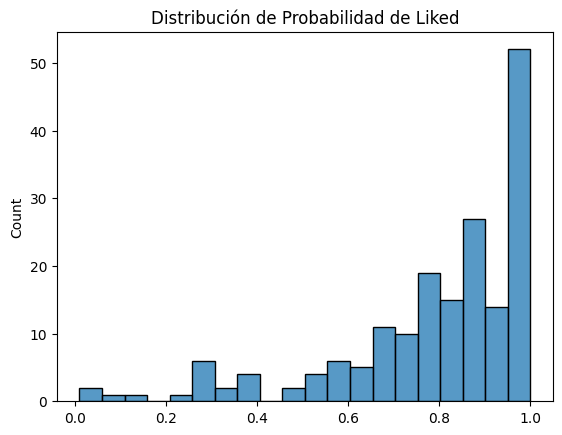

In [ ]:
# Distribución de probabilidad
# Vemos una gran cantidad de probabilidad = 1 y muy reducida por debajo de 0.8.
# El overfitting es probable.
sns.histplot(y_pred_proba, bins=20)
plt.title("Distribución de Probabilidad de Liked")
plt.show()

In [ ]:
# Desbalance de clases
# Existe un fuerte sesgo hacia la clase mayoritaria.
# El desbalanceo sesga el modelo hacia la predicción de liked, generando overfitting.
model_df["liked"].value_counts(normalize=True)

liked
1.0    0.806167
0.0    0.193833
Name: proportion, dtype: float64

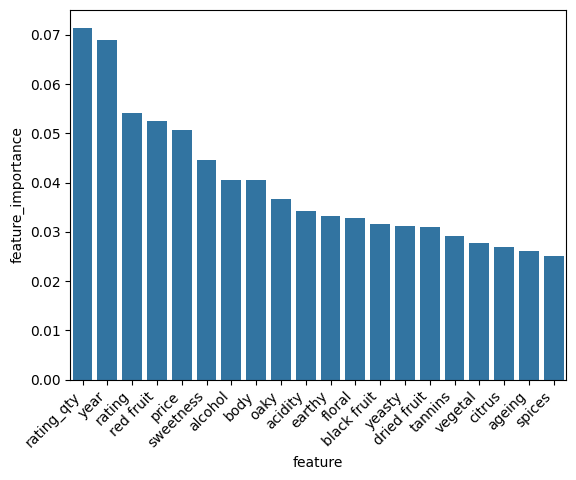

In [ ]:
# Feature importance
# Si bien hay ciertas columnas con mayor poder predictivo,
# no hay un extremo o una columna que de suficiente evidencia de incluir una dimensión con multicolinealidad con la variable objetivo

import seaborn as sns
import matplotlib.pyplot as plt

importances = model.feature_importances_
cols_importance = dict(zip(X.columns, importances))
cols_importance = pd.DataFrame(data=cols_importance.values(), index=cols_importance.keys(), columns=["feature_importance"]).sort_values(by="feature_importance", ascending=False)
cols_importance = cols_importance.reset_index(drop=False).rename(columns={"index": "feature"})

plt.figure()
sns.barplot(cols_importance[:20], x="feature", y="feature_importance")
plt.xticks(rotation=45, ha='right')
plt.show()


In [26]:
for i, tree in enumerate(model.estimators_):
    print(f"Profundidad del árbol {i+1}: {tree.tree_.max_depth}")

Profundidad del árbol 1: 18
Profundidad del árbol 2: 19
Profundidad del árbol 3: 18
Profundidad del árbol 4: 18
Profundidad del árbol 5: 16
Profundidad del árbol 6: 21
Profundidad del árbol 7: 19
Profundidad del árbol 8: 22
Profundidad del árbol 9: 18
Profundidad del árbol 10: 17
Profundidad del árbol 11: 16
Profundidad del árbol 12: 21
Profundidad del árbol 13: 29
Profundidad del árbol 14: 15
Profundidad del árbol 15: 19
Profundidad del árbol 16: 20
Profundidad del árbol 17: 22
Profundidad del árbol 18: 16
Profundidad del árbol 19: 23
Profundidad del árbol 20: 16
Profundidad del árbol 21: 18
Profundidad del árbol 22: 17
Profundidad del árbol 23: 17
Profundidad del árbol 24: 16
Profundidad del árbol 25: 14
Profundidad del árbol 26: 23
Profundidad del árbol 27: 19
Profundidad del árbol 28: 19
Profundidad del árbol 29: 20
Profundidad del árbol 30: 17
Profundidad del árbol 31: 20
Profundidad del árbol 32: 22
Profundidad del árbol 33: 20
Profundidad del árbol 34: 13
Profundidad del árbol 3

### Ajuste del overfitting

- Ajustar solamente los hiperparámetros no está trayendo buenos resultados. El desbalance de clases es muy fuerte.
- **`Approach 1`**: aplicar imbalanced learning para generar samplings del dataset original.
- **`Approach 2`**: aplicar un top_n mayor y un d menor al syntheticuser, para así poder tener más resultados que no le gustaron al usuario.


In [56]:
# Ajuste de hiper parámetros
# https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
model = RandomForestClassifier(n_estimators=200, max_depth=6, min_samples_split=2, min_samples_leaf=1, max_features="sqrt", class_weight="balanced")
model.fit(X_train, y_train)

y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

y_train_proba = model.predict_proba(X_train)[:, 1]
y_train_pred = model.predict(X_train)

print("Train Metrics:\n")
print(classification_report(y_train, y_train_pred))
print("AUC Train:", roc_auc_score(y_train, y_train_proba))
print("\n----------------------------------------------------\n")
print("Test Metrics:\n")
print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_pred_proba))


Train Metrics:

              precision    recall  f1-score   support

         0.0       0.50      0.72      0.59       141
         1.0       0.92      0.83      0.87       585

    accuracy                           0.80       726
   macro avg       0.71      0.77      0.73       726
weighted avg       0.84      0.80      0.82       726

AUC Train: 0.8659695702248893

----------------------------------------------------

Test Metrics:

              precision    recall  f1-score   support

         0.0       0.24      0.37      0.29        35
         1.0       0.83      0.71      0.77       147

    accuracy                           0.65       182
   macro avg       0.53      0.54      0.53       182
weighted avg       0.71      0.65      0.67       182

AUC: 0.5910592808551993
